# 07 — Un réseau de neurones sur données tabulaires

Les notebooks 04-05 ont montré qu'un modèle linéaire faisait aussi bien que les arbres sur
ce problème. Reste à tester le deep learning, puisque c'est au programme et que la question
revient toujours en entretien : *un réseau de neurones aurait-il fait mieux ?*

Cadre identique aux autres modèles : mêmes features (sans fuite), même découpage
train/test, même pré-traitement en amont. Réseau volontairement simple. Keras 3 avec le
backend PyTorch (CPU — le modèle est trop petit pour qu'un GPU change quoi que ce soit).

In [1]:
import os, sys, warnings
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"          # à faire avant d'importer keras
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import keras
print("backend keras :", keras.backend.backend())

backend keras : torch


In [2]:
import joblib
from src import modeling, features, deep

d = joblib.load(ROOT / "models" / "baseline_logit.joblib")
X_tr, y_tr, X_te, y_te = d["X_tr"], d["y_tr"], d["X_te"], d["y_te"]

# Pré-traitement : imputation + standardisation + one-hot, ajusté sur le train seulement.
prep = modeling.preprocesseur(pour_arbres=False).fit(X_tr, y_tr)
Xtr = prep.transform(X_tr); Xte = prep.transform(X_te)
print("entrée du réseau :", Xtr.shape[1], "variables après encodage")

entrée du réseau : 71 variables après encodage


In [3]:
from sklearn.model_selection import train_test_split
Xtr_f, Xval_f, ytr_f, yval_f = train_test_split(
    Xtr, y_tr.to_numpy(), test_size=0.2, stratify=y_tr, random_state=42)

keras.utils.set_random_seed(42)
model = deep.build_mlp(Xtr.shape[1], largeur=(64, 32), dropout=0.3, lr=1e-3)
model.summary(print_fn=lambda s: print(s))

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)          

arrêt après 49 époques


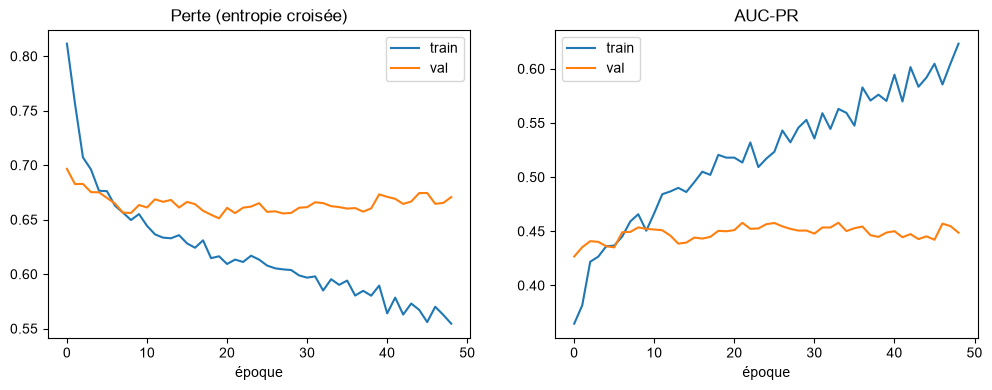

In [4]:
hist = deep.train_mlp(model, Xtr_f, ytr_f, Xval_f, yval_f, epochs=150, patience=15)
print(f"arrêt après {len(hist.history['loss'])} époques")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(hist.history["loss"], label="train"); a1.plot(hist.history["val_loss"], label="val")
a1.set(title="Perte (entropie croisée)", xlabel="époque"); a1.legend()
a2.plot(hist.history["ap"], label="train"); a2.plot(hist.history["val_ap"], label="val")
a2.set(title="AUC-PR", xlabel="époque"); a2.legend()
from src import plotting
plotting.save(fig, "07_mlp_apprentissage")
plt.show()

In [5]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
s_nn = deep.predict_proba(model, Xte)

perf_nn = {
    "AP (PR-AUC)": average_precision_score(y_te, s_nn),
    "ROC AUC": roc_auc_score(y_te, s_nn),
    "Brier": brier_score_loss(y_te, s_nn),
}
# comparaison avec les modèles des notebooks 04-05 (mêmes train/test)
autres = pd.read_csv(ROOT / "results" / "tables" / "05_performance_test.csv", index_col=0)
tab = pd.concat([autres[["AP (PR-AUC)", "ROC AUC", "Brier"]],
                 pd.DataFrame(perf_nn, index=["Réseau de neurones (MLP)"])]).round(3)
tab.to_csv(ROOT / "results" / "tables" / "07_comparaison_mlp.csv")
tab

,AP (PR-AUC),ROC AUC,Brier
Régression logistique,0.442,0.658,0.231
Gradient boosting,0.435,0.649,0.212
Réseau de neurones (MLP),0.436,0.646,0.236


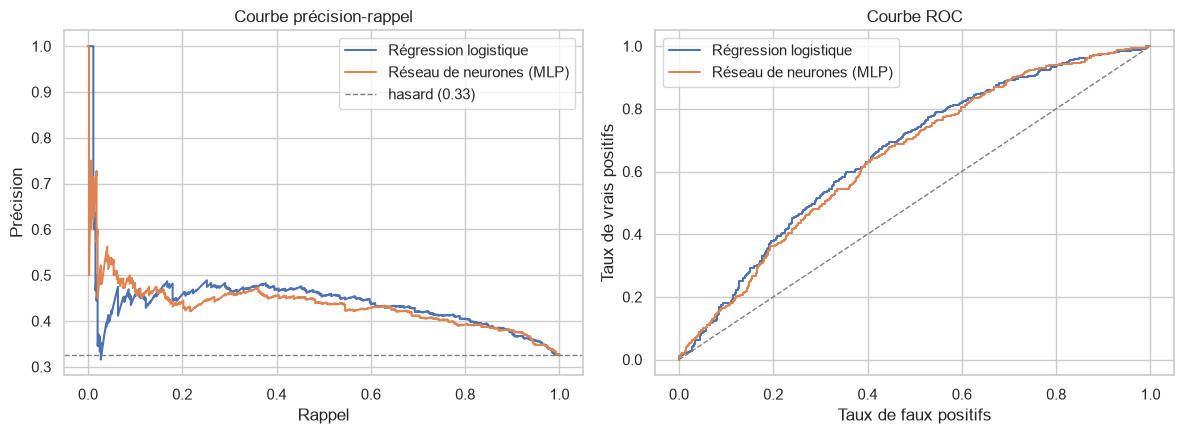

In [6]:
# Courbes sur le test, réseau vs référence linéaire.
from src import plotting
logit = d["pipeline"]
s_logit = logit.predict_proba(X_te)[:, 1]
fig = plotting.courbes_pr_roc({
    "Régression logistique": (y_te.values, s_logit),
    "Réseau de neurones (MLP)": (y_te.values, s_nn),
})
plotting.save(fig, "07_pr_roc_mlp")
plt.show()

## Verdict

Le MLP arrive **au même niveau que la régression logistique** (AP et AUC à deux ou trois
millièmes près), pour un temps de mise au point bien plus long et un modèle beaucoup moins
lisible. Aucun gain.

C'est cohérent avec tout le reste du projet : le signal disponible dans l'alimentation et
le mode de vie déclarés est faible et essentiellement additif. Un réseau de neurones sait
capturer des interactions complexes — mais s'il n'y en a pas d'exploitables, il ne fait que
retrouver, plus lentement, ce qu'un modèle linéaire donne directement. Sur ~4 000 exemples
d'entraînement et 30 variables, il n'a par ailleurs pas le volume qui lui donnerait
l'avantage.

Le deep learning aurait un intérêt sur ce type de données avec : beaucoup plus
d'observations, des variables brutes non agrégées (les aliments un par un plutôt que les
macronutriments), ou des données de nature différente (signaux, images, texte). Pas ici.